In [1]:
from pyscf import gto, scf, cc
import numpy as np
from jax import numpy as jnp
from jax import vmap, jvp, jit
import jax
from functools import partial

a = 2 # 2aB
nH = 2
atoms = ""
for i in range(nH):
    atoms += f"N {i*a:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)

nfrozen = 2
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()
# et = mycc.ccsd_t()
# print(mycc.e_tot + et)
mycc.energy()

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-14-generic', version='#14~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Jan 15 15:52:10 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Fri Feb 13 17:04:58 2026
PySCF version 2.11.0
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT HEAD (branch master) 3d1768f5e33b144b606c3d2c81c12ee54d794501

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 N      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr 

np.float64(-0.14351120721637967)

In [2]:
# example for PT2
options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 100,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'ccsd_pt2',
            'dt':0.005,
            'free_projection':False,
            'fp_abs': False,
            'group': False,
            'ad_mode':None,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted import prep
prep.prep_afqmc(mycc,options,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# If you import pyscf cc modules and use MPI for AFQMC in the same script, finalize MPI before calling the AFQMC driver.
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (5, 5)
# Number of basis functions: 8
# Number of Cholesky vectors: 42
#


In [3]:
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 
from ad_afqmc import config
from ad_afqmc.prop_unrestricted import sampling
import time

In [30]:
ham_data, ham, prop, trial, wave_data, sampler, observable, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)
h0 = ham_data['h0']

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

t1, t2, e0, e1 = trial.calc_energy_pt(prop_data["walkers"], ham_data, wave_data)
ept_sp = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2
ept = jnp.array(jnp.sum(ept_sp) / prop.n_walkers)
prop_data["e_estimate"] = ept
eci = trial.calc_energy(
    prop_data['walkers'], ham_data, wave_data)
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(ept)
print(ept-mycc.e_tot)

# Hostname: sharmagroup-rn
# System Type: Linux
# Machine Type: x86_64
# Processor: x86_64
# Number of MPI ranks: 1
#
# norb: 8
# nelec: (5, 5)
#
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 100
# seed: 2
# walker_type: rhf
# trial: ccsd_pt2
# dt: 0.005
# free_projection: False
# fp_abs: False
# group: False
# use_gpu: False
# n_exp_terms: 6
# symmetry: False
# save_walkers: False
# ene0: 0.0
# n_batch: 1
# maxError: 0.001
#
-108.66698489945266
4.78045689078499e-06


In [31]:
from ad_afqmc.prop_unrestricted import wavefunctions_restricted
trial_stocc = wavefunctions_restricted.stoccsd(trial.norb, trial.nelec, n_batch=options["n_batch"])
trial_stocc.nslater = 5000
wave_data['stocc'] = trial_stocc.get_stocc(wave_data, prop_data)
e_stocc = trial.calc_energy(wave_data['stocc'], ham_data, wave_data)
o_stocc = trial.calc_overlap(wave_data['stocc'], wave_data)
e_stocc = jnp.sum(o_stocc * e_stocc) / jnp.sum(o_stocc)
print(e_stocc-mycc.e_tot)

(0.003395264785723384-1.8160210949712193e-06j)


In [6]:
trial_stocc

stoccsd(norb=8, nelec=(5, 5), n_opt_iter=30, n_batch=1)

In [25]:
from jax import lax

@partial(jit, static_argnums=(0,3,4))
def stocc_block_scan(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict,
):
    """Block scan function. Propagation and energy calculation."""
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            self.n_prop_steps,
            prop.n_walkers,
            self.n_chol,
        ),
    )
    _step_scan_wrapper = lambda x, y: self._step_scan(
        x, y, ham_data, prop, trial, wave_data
    )
    prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
    prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
        prop_data["weights"]
    )

    prop_data = prop.orthonormalize_walkers(prop_data)
    prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
    # otg, eg, et = trial.calc_energy_mixed(prop_data["walkers"],ham_data,wave_data)
    eg = jnp.real(trial.calc_energy(prop_data["walkers"],ham_data,wave_data))
    (et, ot) = trial_stocc.calc_energy_overlap_stocc(prop_data["walkers"], ham_data, wave_data)
    t1, t2, e0, e1 = trial.calc_energy_pt(prop_data["walkers"], ham_data, wave_data)
    
    eg = jnp.where(
        jnp.abs(eg - prop_data["e_estimate"]) > jnp.sqrt(2.0 / prop.dt),
        prop_data["e_estimate"],
        eg,
    )
    
    wt = prop_data["weights"]
    wp = wt * ot / prop_data["overlaps"]

    blk_wt = jnp.sum(wt)
    blk_wp = jnp.sum(wp)
    blk_eg = jnp.sum(eg*wt) / blk_wt
    blk_et = jnp.sum(et*wp) / blk_wp
    blk_t1 = jnp.sum(t1*wt) / blk_wt
    blk_t2 = jnp.sum(t2*wt) / blk_wt
    blk_e0 = jnp.sum(e0*wt) / blk_wt
    blk_e1 = jnp.sum(e1*wt) / blk_wt

    prop_data["pop_control_ene_shift"] = (
        0.9 * prop_data["pop_control_ene_shift"] + 0.1 * blk_eg
        )

    return prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)

@partial(jit, static_argnums=(0,3,4))
def stocc_sr_scan(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict,
):
        
    def _block_scan_wrapper(x,_):
        return stocc_block_scan(self,x,ham_data,prop,trial,wave_data)
    
    prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)\
        = lax.scan(
        _block_scan_wrapper, prop_data, None, length = self.n_ene_blocks
    )
    prop_data = prop.stochastic_reconfiguration_local(prop_data)
    prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
    return prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)

@partial(jit, static_argnums=(0,3,4))
def stocc_obvervation(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict,
):
    def _sr_block_scan_wrapper(x,_):
        return stocc_sr_scan(self, x, ham_data, prop, trial, wave_data)

    prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
    prop_data["n_killed_walkers"] = 0
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]
    prop_data, (blk_wt, blk_wp, blk_eg, blk_et, blk_t1, blk_t2, blk_e0, blk_e1)\
        = lax.scan(
        _sr_block_scan_wrapper, prop_data, None, length = self.n_sr_blocks
    )
    prop_data["n_killed_walkers"] /= (
        self.n_sr_blocks * self.n_ene_blocks * prop.n_walkers
    )

    wt = jnp.sum(blk_wt)
    wp = jnp.sum(blk_wp)
    eg = jnp.sum(blk_eg * blk_wt) / wt
    et = jnp.sum(blk_et * blk_wp) / wp
    t1 = jnp.sum(blk_t1 * blk_wt) / wt
    t2 = jnp.sum(blk_t2 * blk_wt) / wt
    e0 = jnp.sum(blk_e0 * blk_wt) / wt
    e1 = jnp.sum(blk_e1 * blk_wt) / wt
    ept = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2

    return prop_data, (wt, wp, eg, et, ept)

In [32]:
e0 = trial._calc_energy_restricted(prop_data["walkers"][0], ham_data, wave_data)

In [33]:
nsample = 50
samples = np.zeros((nsample, 5))
samples[0,:] = [100, 100, e0.real, e_stocc.real, ept.real]
for n in range(1,nsample):
    prop_data, (wt, wp, e_hf, e_stocc, e_ccpt) \
        = stocc_obvervation(sampler, prop_data, ham_data, prop, trial, wave_data)
    print(n, wt.real, wp.real, e_hf.real, e_stocc.real, e_ccpt.real)
    samples[n,:] = [wt.real, wp.real, e_hf.real, e_stocc.real, e_ccpt.real]

1 498.72530484901927 524.3314754899088 -108.6266333652964 -108.66691998957134 -108.66894095081797
2 499.77120928853736 537.1614839209217 -108.66698381779851 -108.66872255810199 -108.66764385752946
3 500.4308181798255 546.0503674207326 -108.69453492732063 -108.67149713717666 -108.67138910708425
4 499.3643244641903 535.1265662794136 -108.65773798709363 -108.67020781155438 -108.66985380855101
5 499.1400164638497 531.9149416309743 -108.65398786414882 -108.66978289206536 -108.66806624317856
6 499.22745472272237 533.411216193482 -108.65754570584447 -108.6682718653657 -108.66801930253376
7 498.707347829935 527.2876874216821 -108.63555541685528 -108.66781317514682 -108.66851007784655
8 498.9209043035468 527.697364086276 -108.63730535032352 -108.66819284355614 -108.66970281582614
9 498.6570826635715 527.8574199904735 -108.63532572172879 -108.66913659438637 -108.66991821544546
10 498.91975091951986 529.7452972192235 -108.64198787397599 -108.66843240411464 -108.66753545295502
11 500.1303552010162

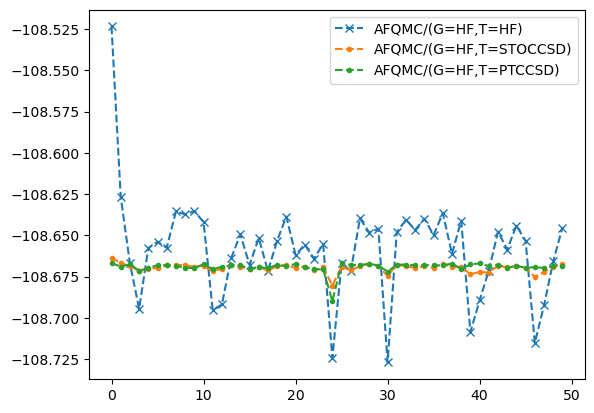

In [34]:
from matplotlib import pyplot as plt
plt.plot(samples[:,2],'x--',label='AFQMC/(G=HF,T=HF)')
plt.plot(samples[:,3],'.--',label='AFQMC/(G=HF,T=STOCCSD)')
plt.plot(samples[:,4],'.--',label='AFQMC/(G=HF,T=PTCCSD)')
plt.legend()
plt.show()

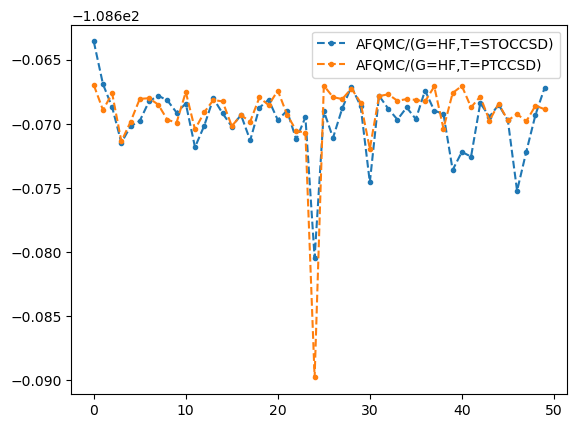

In [35]:
plt.plot(samples[:,3],'.--',label='AFQMC/(G=HF,T=STOCCSD)')
plt.plot(samples[:,4],'.--',label='AFQMC/(G=HF,T=PTCCSD)')
plt.legend()
plt.show()

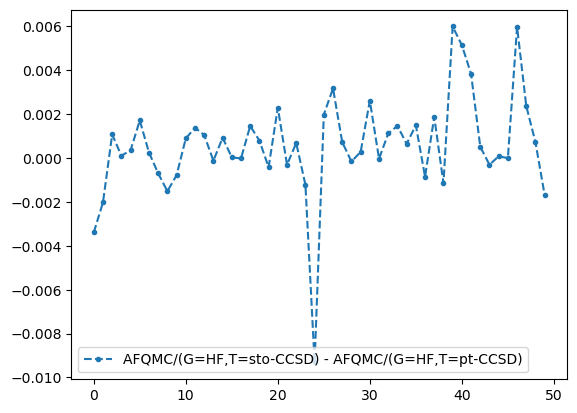

In [36]:
plt.plot(samples[:,4]-samples[:,3],'.--',label='AFQMC/(G=HF,T=sto-CCSD) - AFQMC/(G=HF,T=pt-CCSD)')
# plt.plot(samples[:,4],'.--',label='AFQMC/(G=HF,T=PTCCSD)')
plt.legend()
plt.show()